# Introduction to the pycox package


In this notebook we introduce the use of `pycox` through an example dataset.
We illustrate the procedure with the `LogisticHazard` method ([paper_link](https://arxiv.org/abs/1910.06724)), but we this can easily be replaced by for example `PMF`, `MTLR` or `DeepHitSingle`.

In the following we will:

- Load the METABRIC survival dataset.
- Process the event labels so the they work with our methods.
- Create a [PyTorch](https://pytorch.org) neural network.
- Fit the model.
- Evaluate the predictive performance using the concordance, Brier score, and negative binomial log-likelihood.

While some knowledge of the [PyTorch](https://pytorch.org) framework is preferable, it is not required for the use of simple neural networks.
For building more advanced network architectures, however, we would recommend looking at [the PyTorch tutorials](https://pytorch.org/tutorials/).

## Imports

You need `sklearn-pandas` which can be installed by uncommenting the following block

In [1]:
! pip install sklearn-pandas
! pip install seaborn
! pip install imbalanced-learn
! pip install lifelines
! pip install pycox

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 4.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=4dedd0427db3a83b66529f8e73502366154c67dfa281125c3688b140cd62811f
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.3/93.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lifelines.utils import concordance_index

from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper 

from sklearn.model_selection import KFold
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
import pickle

import torch.nn as nn
from sklearn.utils import resample
import shutil


`pycox` is built on top of [PyTorch](https://pytorch.org) and [torchtuples](https://github.com/havakv/torchtuples), where the latter is just a simple way of training neural nets with less boilerplate code.

In [3]:
import torch # For building the networks 
import torchtuples as tt # Some useful functions

We import the `metabric` dataset, the `LogisticHazard` method ([paper_link](https://arxiv.org/abs/1910.06724)) also known as [Nnet-survival](https://peerj.com/articles/6257/), and `EvalSurv` which simplifies the evaluation procedure at the end.

You can alternatively replace `LogisticHazard` with, for example, `PMF` or `DeepHitSingle`, which should both work in this notebook.

In [4]:
# from pycox.datasets import metabric
from pycox.models import CoxTime
from pycox.models import LogisticHazard
from pycox.models import PMF
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv

In [5]:
# We also set some seeds to make this reproducable.
# Note that on gpu, there is still some randomness.
np.random.seed(1234)
_ = torch.manual_seed(123)

## Dataset

We load the METABRIC data set as a pandas DataFrame and split the data in in train, test and validation.

The `duration` column gives the observed times and the `event` column contains indicators of whether the observation is an event (1) or a censored observation (0).

In [6]:


# def load_indices(file_path):
#     """Load file indices from the given text file."""
#     with open(file_path, 'r') as f:
#         indices = {line.strip() for line in f.readlines() if line.strip()}
#     return indices

# def extract_core_filename(file_name):
#     """Extract the core filename without extensions and suffixes."""
#     return file_name.split('.')[0]  # Consider only the part before the first period

# def filter_and_copy_files(source_dir, destination_dir, indices):
#     """Filter and copy files from source_dir to destination_dir based on indices."""
#     if not os.path.exists(destination_dir):
#         os.makedirs(destination_dir, exist_ok=True)
    
#     source_files = os.listdir(source_dir)
    
#     files_copied = 0
#     for file_name in source_files:
#         file_index = extract_core_filename(file_name)  # Extract core filename
#         if any(idx in file_index for idx in indices):  # Looser matching condition
#             shutil.copy(os.path.join(source_dir, file_name), os.path.join(destination_dir, file_name))
#             files_copied += 1
    
#     # print(f'Copied {files_copied} files to {destination_dir}')

# def process_folds(base_path, gog_features_folder, output_base):
#     """Process each fold and organize the dataset accordingly."""
#     for fold in range(1, 6):  # Assuming 5 folds
#         fold_name = f'fold_{fold}'
#         train_idx_path = os.path.join(base_path, f'splt_idx/{fold_name}_train.txt')
#         test_idx_path = os.path.join(base_path, f'splt_idx/{fold_name}_test.txt')
        
#         if os.path.exists(train_idx_path) and os.path.exists(test_idx_path):
#             print(f'Processing {fold_name}...')
#             train_indices = load_indices(train_idx_path)
#             test_indices = load_indices(test_idx_path)
            
#             fold_output_dir = os.path.join(output_base, fold_name)
#             train_output_dir = os.path.join(fold_output_dir, 'train')
#             test_output_dir = os.path.join(fold_output_dir, 'test')
            
#             filter_and_copy_files(gog_features_folder, train_output_dir, train_indices)
#             filter_and_copy_files(gog_features_folder, test_output_dir, test_indices)
#         else:
#             print(f'Missing index file for {fold_name}')

# # Define paths
# base_path = '/kaggle/input/gog-dota'
# gog_features_folder = '/kaggle/input/time-to-accident-dataset-2/gog_features'
# output_base = '/kaggle/working/filtered_dataset'

# # Run the process
# process_folds(base_path, gog_features_folder, output_base)
# print("Dataset processing completed.")


In [7]:
# # Paths to your folders
# training_folder = '/kaggle/working/filtered_dataset/fold_5/train'
# testing_folder = '/kaggle/working/filtered_dataset/fold_5/test'
# toas_folder = '/kaggle/input/time-to-accident-dataset/toas/toas'

# # Feature keys
# feature_keys = ['frame_embeddings', 'object_level_features', 'graph_embeddings']
# FPS = 10

# def process_folder(folder_name):
#     features_list = []
#     durations_list = []
#     events_list = []

#     for npz_file in os.listdir(folder_name):
#         if npz_file.endswith('.npz'):
#             file_id = os.path.splitext(npz_file)[0]
#             npz_path = os.path.join(folder_name, npz_file)
            
#             npz_data = np.load(npz_path)
#             combined_features = []
            
#             for key in feature_keys:
#                 if key in npz_data:
#                     features = npz_data[key].flatten()
#                     combined_features.extend(features)
            
#             if combined_features:
#                 features_list.append(combined_features)
#                 txt_path = os.path.join(toas_folder, f"{file_id}.txt")
                
#                 if os.path.exists(txt_path):
#                     with open(txt_path, 'r') as f:
#                         frame_count = float(f.read().strip())
#                     duration = frame_count / FPS
#                     event = 1
#                 else:
#                     duration = 5  # Censored event
#                     event = 0
                
#                 durations_list.append(duration)
#                 events_list.append(event)

#     num_features = len(features_list[0]) if features_list else 0
#     data = pd.DataFrame(features_list, columns=[f'x{i}' for i in range(num_features)])
#     data['duration'] = durations_list
#     data['event'] = events_list
    
#     return data

# def apply_upsampling(data):
#     bin_size = 0.5
#     bins = np.arange(0, 5 + bin_size, bin_size)
#     data['duration_bin'] = pd.cut(data['duration'], bins=bins, include_lowest=True)
#     bin_counts = data['duration_bin'].value_counts()
#     median_count = int(bin_counts.median())
#     median_count = max(median_count, bin_counts.max(), 1)
    
#     bins_to_upsample = [b for b in bin_counts.index if bin_counts[b] < median_count and not (2.5 <= b.left < 3.0)]
#     upsampled_data = []
    
#     for bin_range in bins_to_upsample:
#         bin_data = data[data['duration_bin'] == bin_range]
#         if not bin_data.empty:
#             upsampled_bin = resample(bin_data, replace=True, n_samples=median_count, random_state=42)
#             upsampled_data.append(upsampled_bin)
    
#     upsampled_data.append(data)
#     data = pd.concat(upsampled_data).drop(columns=['duration_bin']).sample(frac=1, random_state=42).reset_index(drop=True)
    
#     return data

# # Process training and validation data
# train_val_data = process_folder(training_folder)

# # Split into training, validation, and testing data
# df_test = process_folder(testing_folder)  # Testing data from the testing folder

# train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle data

# # Split the data into 80% train and 20% validation
# df_train = train_val_data.sample(frac=0.8, random_state=42)
# df_val = train_val_data.drop(df_train.index)

# # Apply upsampling only to training data
# df_train = apply_upsampling(df_train)

# # Standardize the features
# scaler = StandardScaler()
# train_features = scaler.fit_transform(df_train.drop(columns=['duration', 'event']))
# val_features = scaler.transform(df_val.drop(columns=['duration', 'event']))
# test_features = scaler.transform(df_test.drop(columns=['duration', 'event']))

# # Convert to tensors
# X_train = torch.tensor(train_features, dtype=torch.float32)
# y_train_duration = torch.tensor(df_train['duration'].values, dtype=torch.float32)
# y_train_event = torch.tensor(df_train['event'].values, dtype=torch.float32)

# X_val = torch.tensor(val_features, dtype=torch.float32)
# y_val_duration = torch.tensor(df_val['duration'].values, dtype=torch.float32)
# y_val_event = torch.tensor(df_val['event'].values, dtype=torch.float32)

# X_test = torch.tensor(test_features, dtype=torch.float32)
# y_test_duration = torch.tensor(df_test['duration'].values, dtype=torch.float32)
# y_test_event = torch.tensor(df_test['event'].values, dtype=torch.float32)

# print("Training shape:", df_train.shape)
# print("Validation shape:", df_val.shape)
# print("Test shape:", df_test.shape)


In [8]:

# Paths to your folders
training_folder = '/kaggle/input/time-to-accident-dataset-2/gog_features/gog_features'
toas_folder = '/kaggle/input/time-to-accident-dataset-2/toas'

# Feature keys
feature_keys = ['frame_embeddings', 'object_level_features', 'graph_embeddings']
FPS = 10

def process_folder(folder_name):
    features_list = []
    durations_list = []
    events_list = []

    for npz_file in os.listdir(folder_name):
        if npz_file.endswith('.npz'):
            file_id = os.path.splitext(npz_file)[0]
            npz_path = os.path.join(folder_name, npz_file)
            
            npz_data = np.load(npz_path)
            combined_features = []
            
            for key in feature_keys:
                if key in npz_data:
                    features = npz_data[key].flatten()
                    combined_features.extend(features)
            
            if combined_features:
                features_list.append(combined_features)
                txt_path = os.path.join(toas_folder, f"{file_id}.txt")
                
                if os.path.exists(txt_path):
                    with open(txt_path, 'r') as f:
                        frame_count = float(f.read().strip())
                    duration = frame_count / FPS
                    event = 1
                else:
                    duration = 5  # Censored event
                    event = 0
                
                durations_list.append(duration)
                events_list.append(event)

    num_features = len(features_list[0]) if features_list else 0
    data = pd.DataFrame(features_list, columns=[f'x{i}' for i in range(num_features)])
    data['duration'] = durations_list
    data['event'] = events_list
    
    return data

def apply_upsampling(data):
    bin_size = 0.5
    bins = np.arange(0, 5 + bin_size, bin_size)
    data['duration_bin'] = pd.cut(data['duration'], bins=bins, include_lowest=True)
    bin_counts = data['duration_bin'].value_counts()
    median_count = int(bin_counts.median())
    median_count = max(median_count, bin_counts.max(), 1)
    
    bins_to_upsample = [b for b in bin_counts.index if bin_counts[b] < median_count and not (2.5 <= b.left < 3.0)]
    upsampled_data = []
    
    for bin_range in bins_to_upsample:
        bin_data = data[data['duration_bin'] == bin_range]
        if not bin_data.empty:
            upsampled_bin = resample(bin_data, replace=True, n_samples=median_count, random_state=42)
            upsampled_data.append(upsampled_bin)
    
    upsampled_data.append(data)
    data = pd.concat(upsampled_data).drop(columns=['duration_bin']).sample(frac=1, random_state=42).reset_index(drop=True)
    
    return data

# Process full dataset
data = process_folder(training_folder)

df_test = data.sample(frac=0.2, random_state=42)
data = data.drop(df_test.index)
df_train = data.sample(frac=0.8, random_state=42)
df_val = data.drop(df_train.index)

# Apply upsampling only to training data
# df_train = apply_upsampling(df_train)

scaler = StandardScaler()
train_features = scaler.fit_transform(df_train.drop(columns=['duration', 'event']))
val_features = scaler.transform(df_val.drop(columns=['duration', 'event']))
test_features = scaler.transform(df_test.drop(columns=['duration', 'event']))

X_train = torch.tensor(train_features, dtype=torch.float32)
y_train_duration = torch.tensor(df_train['duration'].values, dtype=torch.float32)
y_train_event = torch.tensor(df_train['event'].values, dtype=torch.float32)

X_val = torch.tensor(val_features, dtype=torch.float32)
y_val_duration = torch.tensor(df_val['duration'].values, dtype=torch.float32)
y_val_event = torch.tensor(df_val['event'].values, dtype=torch.float32)

X_test = torch.tensor(test_features, dtype=torch.float32)
y_test_duration = torch.tensor(df_test['duration'].values, dtype=torch.float32)
y_test_event = torch.tensor(df_test['event'].values, dtype=torch.float32)

print("Training shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)


Training shape: (1024, 44802)
Validation shape: (256, 44802)
Test shape: (320, 44802)


In [9]:
df_train.head()
df_test.head()
df_val.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x44792,x44793,x44794,x44795,x44796,x44797,x44798,x44799,duration,event
1,-0.390555,-0.493805,1.442831,-0.210315,-0.076959,1.631178,-0.459697,2.406825,2.621112,1.374672,...,0.088202,0.119772,0.869363,0.115042,1.663339,1.959234,1.271638,2.774092,1.7,1
8,-0.192187,-0.008580,0.977013,1.844758,-0.125805,1.623889,0.082403,-0.158145,0.478739,3.419350,...,0.270618,0.308261,0.798728,0.298795,1.670113,1.293263,1.305671,1.619817,5.0,0
13,-0.382942,-0.315571,0.038395,-0.067033,-0.378911,1.620809,-0.162620,1.300978,2.447934,1.646472,...,0.595055,0.610346,0.815570,0.572129,0.878358,1.044118,1.196651,1.470878,2.6,1
14,-0.368493,-0.003189,0.638294,0.401926,-0.123133,1.569624,-0.201721,-0.086175,1.879657,1.343008,...,0.399740,0.353104,0.882777,0.357734,1.102952,1.829831,1.140460,2.355436,2.7,1
17,-0.229079,-0.012158,1.525170,-0.222304,-0.093415,1.525516,-0.398012,-0.607333,2.223963,0.432504,...,0.007919,0.015883,1.370645,0.014599,0.191576,-0.000484,2.704282,0.524190,2.0,1


## Feature transforms

The METABRIC dataset has  9 covariates: `x0, ..., x8`.
We will standardize the 5 numerical covariates, and leave the binary covariates as is.
Note that PyTorch require variables of type `'float32'`.

Here we use the `sklearn_pandas.DataFrameMapper` to make feature mappers, but this has nothing to do the the `pycox` package.

In [10]:
cols_standardize = [f'x{i}' for i in range(44800)]  
cols_leave = []  

# Create standardization transformations for all features
standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

# Initialize DataFrameMapper with standardization applied to all features
x_mapper = DataFrameMapper(standardize + leave)

In [11]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')

## Label transforms

The survival methods require individual label transforms, so we have included a proposed `label_transform` for each method.
For most of them the `label_transform` is just a shorthand for the class `pycox.preprocessing.label_transforms.LabTransDiscreteTime`.

The `LogisticHazard` is a discrete-time method, meaning it requires discretization of the event times to be applied to continuous-time data.
We let `num_durations` define the size of this (equidistant) discretization grid, meaning our network will have `num_durations` output nodes.

In [12]:
# labtrans = CoxTime.label_transform()
# get_target = lambda df: (df['duration'].values, df['event'].values)
# y_train = labtrans.fit_transform(*get_target(df_train))
# y_val = labtrans.transform(*get_target(df_val))
# durations_test, events_test = get_target(df_test)
# val = tt.tuplefy(x_val, y_val)

In [13]:
num_durations = 50
labtrans = LogisticHazard.label_transform(num_durations)
get_target = lambda df: (df['duration'].values, df['event'].values)
y_train = labtrans.fit_transform(*get_target(df_train))
y_val = labtrans.transform(*get_target(df_val))

train = (x_train, y_train)
val = (x_val, y_val)

# We don't need to transform the test labels
durations_test, events_test = get_target(df_test)

In [14]:
# num_durations = 50  # Number of intervals (50 parts)

# # Define custom cuts for a fixed 5-second interval divided into 50 parts
# custom_cuts = np.linspace(0, 5, num=num_durations+1)  # 50 intervals within the 5-second range

# # Use custom cuts with LogisticHazard
# labtrans = LogisticHazard.label_transform(cuts=custom_cuts)
# # labtrans = PMF.label_transform(cuts=custom_cuts)
# # labtrans = DeepHitSingle.label_transform(cuts=custom_cuts)


# get_target = lambda df: (df['duration'].values, df['event'].values)
# y_train = labtrans.fit_transform(*get_target(df_train))
# y_val = labtrans.transform(*get_target(df_val))

# train = (x_train, y_train)
# val = (x_val, y_val)

# # We don't need to transform the test labels
# durations_test, events_test = get_target(df_test)

In [15]:
type(labtrans)

pycox.preprocessing.label_transforms.LabTransDiscreteTime

The `labtrans.cuts` contains the discretization grid. This will later be used to obtain the right time-scale for survival predictions.

In [16]:
labtrans.cuts

array([0.        , 0.10204082, 0.20408163, 0.30612245, 0.40816327,
       0.51020408, 0.6122449 , 0.71428571, 0.81632653, 0.91836735,
       1.02040816, 1.12244898, 1.2244898 , 1.32653061, 1.42857143,
       1.53061224, 1.63265306, 1.73469388, 1.83673469, 1.93877551,
       2.04081633, 2.14285714, 2.24489796, 2.34693878, 2.44897959,
       2.55102041, 2.65306122, 2.75510204, 2.85714286, 2.95918367,
       3.06122449, 3.16326531, 3.26530612, 3.36734694, 3.46938776,
       3.57142857, 3.67346939, 3.7755102 , 3.87755102, 3.97959184,
       4.08163265, 4.18367347, 4.28571429, 4.3877551 , 4.48979592,
       4.59183673, 4.69387755, 4.79591837, 4.89795918, 5.        ])

Now, `y_train` is a tuple with the indices of the discretized times, in addition to event indicators.

In [17]:
y_train

(array([49, 49, 49, ..., 28, 24,  1]),
 array([0., 0., 0., ..., 1., 1., 1.], dtype=float32))

In [18]:
labtrans.cuts[y_train[0]]

array([5.        , 5.        , 5.        , ..., 2.85714286, 2.44897959,
       0.10204082])

## Neural net

We make a neural net with `torch`.
For simple network structures, we can use the `MLPVanilla` provided by `torchtuples`.
For building more advanced network architectures, see for example [the tutorials by PyTroch](https://pytorch.org/tutorials/).

The following net is an MLP with two hidden layers (with 32 nodes each), ReLU activations, and `out_features` output nodes.
We also have batch normalization and dropout between the layers.

In [19]:
in_features = x_train.shape[1]
num_nodes = [64, 32]  # Increased first layer size
out_features = labtrans.out_features
batch_norm = True
dropout = 0.5  # Increased dropout rate to reduce overfitting

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm, dropout)

If you instead want to build this network with `torch` you can uncomment the following code.
It is essentially equivalent to the `MLPVanilla`, but without the `torch.nn.init.kaiming_normal_` weight initialization.

In [20]:
class MLPModel(nn.Module):
    def __init__(self, in_features, out_features, dropout_rates=[0.3, 0.4, 0.5], batch_norm=True):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0]),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[1]),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[2]),

            nn.Linear(32, out_features)  # Output layer
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate model
in_features = x_train.shape[1]
out_features = labtrans.out_features  # Based on survival analysis or classification
net = MLPModel(in_features, out_features)


In [21]:
# net = torch.nn.Sequential(
#     torch.nn.Linear(in_features, 32),
#     torch.nn.ReLU(),
#     torch.nn.BatchNorm1d(32),
#     torch.nn.Dropout(0.1),
    
#     torch.nn.Linear(32, 32),
#     torch.nn.ReLU(),
#     torch.nn.BatchNorm1d(32),
#     torch.nn.Dropout(0.1),
    
#     torch.nn.Linear(32, out_features)
# )

## Training the model

To train the model we need to define an optimizer. You can choose any `torch.optim` optimizer, or use one from `tt.optim`.
The latter is built on top of the `torch` optimizers, but with some added functionality (such as not requiring `net.parameters()` as input and the `model.lr_finder` for finding suitable learning rates).
We will here use the `Adam` optimizer with learning rate 0.01.

We also set `duration_index` which connects the output nodes of the network the the discretization times. This is only useful for prediction and does not affect the training procedure.

The `LogisticHazard` can also take the argument `device` which can be use to choose between running on the CPU and GPU. The default behavior is to run on a GPU if it is available, and CPU if not.
See `?LogisticHazard` for details.

In [22]:
model = LogisticHazard(net, tt.optim.Adam(0.01), duration_index=labtrans.cuts)
# model = PMF(net, tt.optim.Adam(0.01), duration_index=labtrans.cuts)
# model = DeepHitSingle(net, tt.optim.Adam(0.0005, weight_decay=0.02), duration_index=labtrans.cuts)

Next, we set the `batch_size` and the number of training `epochs`.

We also include the `EarlyStopping` callback to stop training when the validation loss stops improving.

In [23]:
batch_size = 64
epochs = 100
callbacks = [tt.cb.EarlyStopping(patience=5, min_delta=0.001)]

We can now train the network and the `log` object keeps track of the training progress.

In [24]:
log = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    val_data=val
)

0:	[1s / 1s],		train_loss: 15.9531,	val_loss: 8.6905
1:	[1s / 2s],		train_loss: 3.9567,	val_loss: 2.3329
2:	[1s / 4s],		train_loss: 2.5446,	val_loss: 1.9843
3:	[1s / 5s],		train_loss: 2.4438,	val_loss: 1.8746
4:	[1s / 6s],		train_loss: 2.2658,	val_loss: 1.8169
5:	[1s / 7s],		train_loss: 2.1547,	val_loss: 1.7776
6:	[1s / 8s],		train_loss: 2.1539,	val_loss: 1.7633
7:	[1s / 9s],		train_loss: 2.1031,	val_loss: 1.7647
8:	[1s / 10s],		train_loss: 2.0336,	val_loss: 1.7438
9:	[1s / 11s],		train_loss: 2.0450,	val_loss: 1.7341
10:	[1s / 12s],		train_loss: 2.0180,	val_loss: 1.7329
11:	[1s / 13s],		train_loss: 1.9413,	val_loss: 1.7326
12:	[1s / 14s],		train_loss: 1.8995,	val_loss: 1.7146
13:	[1s / 16s],		train_loss: 1.9366,	val_loss: 1.7043
14:	[1s / 17s],		train_loss: 1.9019,	val_loss: 1.7030
15:	[1s / 19s],		train_loss: 1.8775,	val_loss: 1.6890
16:	[1s / 20s],		train_loss: 1.7892,	val_loss: 1.6720
17:	[1s / 21s],		train_loss: 1.8264,	val_loss: 1.6711
18:	[1s / 23s],		train_loss: 1.7876,	val_loss

/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


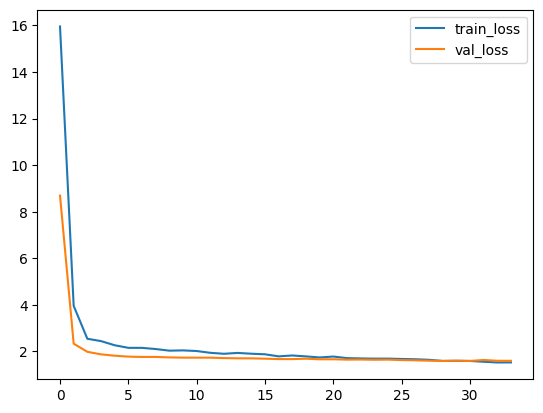

In [25]:
_ = log.plot()

After termination, the `EarlyStopping` callback loads the best performing model (in terms of validation loss).
We can verify this by comparing the minimum validation loss to the validation score of the trained `model`.

In [26]:
log.to_pandas().val_loss.min()

1.5905671119689941

In [27]:
model.score_in_batches(val)

{'loss': 1.5905671119689941}

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

In [28]:
surv = model.predict_surv_df(x_test)
surv_test = model.predict_surv_df(x_test)

Grid Search for Optimal Threshold:
Threshold: 0.10, MAE: 0.6168 seconds
Threshold: 0.20, MAE: 0.5327 seconds
Threshold: 0.30, MAE: 0.4913 seconds
Threshold: 0.40, MAE: 0.4545 seconds
Threshold: 0.50, MAE: 0.4376 seconds
Threshold: 0.60, MAE: 0.4459 seconds
Threshold: 0.70, MAE: 0.4565 seconds
Threshold: 0.80, MAE: 0.5181 seconds
Threshold: 0.90, MAE: 0.6402 seconds
Optimal Threshold: 0.50, with MAE: 0.4376 seconds

Dynamic Threshold: 0.9539
MAE with Dynamic Threshold: 0.8548 seconds
MAE with Weighted Average: 1.5488 seconds


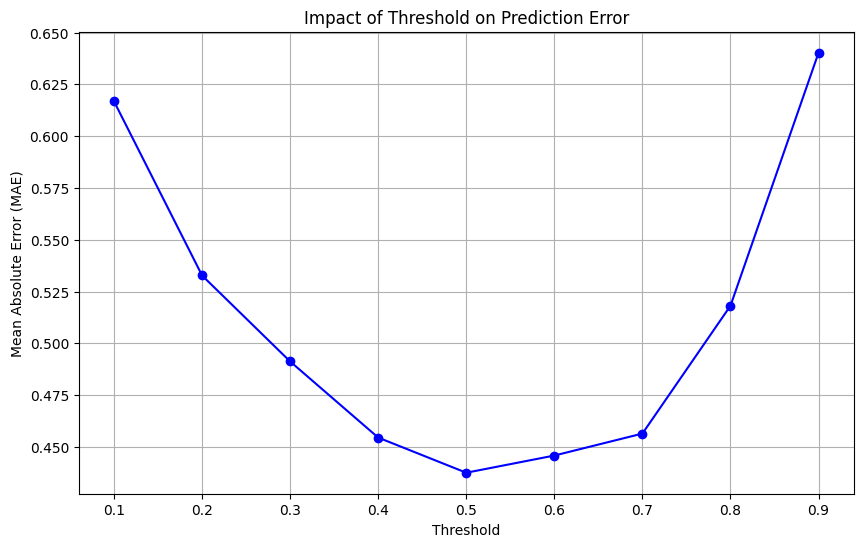


Metrics with Optimal Threshold:
Mean Absolute Error (MAE): 0.4376 seconds
Mean Squared Error (MSE): 0.8654 seconds^2
C-index: 0.1743

True vs Predicted Times (for same samples as chart):
Sample 1: True Time = 5.0000, Predicted Time = 5.0000
Sample 2: True Time = 2.6000, Predicted Time = 2.3469
Sample 3: True Time = 5.0000, Predicted Time = 5.0000
Sample 4: True Time = 5.0000, Predicted Time = 5.0000
Sample 5: True Time = 5.0000, Predicted Time = 5.0000
Sample 6: True Time = 2.8000, Predicted Time = 2.6531
Sample 7: True Time = 1.6000, Predicted Time = 2.7551
Sample 8: True Time = 2.8000, Predicted Time = 2.5510
Sample 9: True Time = 1.9000, Predicted Time = 2.9592
Sample 10: True Time = 2.2000, Predicted Time = 2.5510
Sample 11: True Time = 4.3000, Predicted Time = 5.0000
Sample 12: True Time = 5.0000, Predicted Time = 5.0000
Sample 13: True Time = 5.0000, Predicted Time = 5.0000
Sample 14: True Time = 5.0000, Predicted Time = 5.0000
Sample 15: True Time = 2.7000, Predicted Time = 2.5

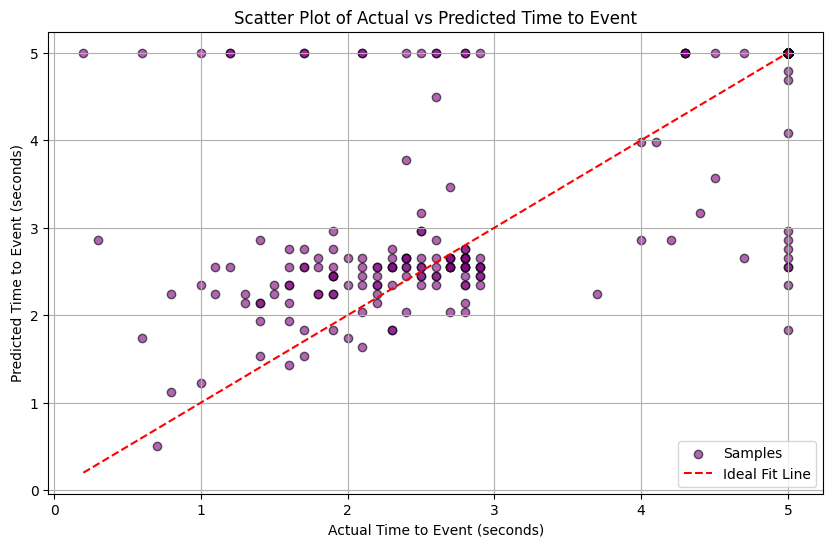

Correlation Coefficient between predicted and actual times: 0.7886


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index  # Ensure lifelines is installed

# Assuming surv_test, true_times_test, and y_test_duration are already defined
# surv_test: Predicted survival functions (DataFrame)
# true_times_test: True durations (numpy array)

# Convert true durations to numpy array if necessary
true_times_test = y_test_duration.numpy()

# 1. Grid Search for Optimal Threshold
threshold_values = np.linspace(0.1, 0.9, 9)  # Thresholds from 0.1 to 0.9
best_threshold = None
best_mae = float('inf')  # Start with a very high MAE

print("Grid Search for Optimal Threshold:")
for threshold in threshold_values:
    predicted_times_test = []
    for col in surv_test.columns:
        time_to_event = surv_test[surv_test[col] < threshold].index[0] if (surv_test[col] < threshold).any() else surv_test.index[-1]
        predicted_times_test.append(time_to_event)
    predicted_times_test = np.array(predicted_times_test)
    
    # Calculate MAE for this threshold
    mae = np.abs(predicted_times_test - true_times_test).mean()
    print(f"Threshold: {threshold:.2f}, MAE: {mae:.4f} seconds")
    
    # Update best threshold
    if mae < best_mae:
        best_mae = mae
        best_threshold = threshold

print(f"Optimal Threshold: {best_threshold:.2f}, with MAE: {best_mae:.4f} seconds")

# 2. Dynamic Threshold (Median Survival Probability)
dynamic_threshold = surv_test.median().median()
print(f"\nDynamic Threshold: {dynamic_threshold:.4f}")

predicted_times_test_dynamic = []
for col in surv_test.columns:
    time_to_event = surv_test[surv_test[col] < dynamic_threshold].index[0] if (surv_test[col] < dynamic_threshold).any() else surv_test.index[-1]
    predicted_times_test_dynamic.append(time_to_event)
predicted_times_test_dynamic = np.array(predicted_times_test_dynamic)

# Calculate MAE for Dynamic Threshold
mae_dynamic = np.abs(predicted_times_test_dynamic - true_times_test).mean()
print(f"MAE with Dynamic Threshold: {mae_dynamic:.4f} seconds")

# 3. Weighted Average Method (Fixed)
predicted_times_test_weighted = []
for col in surv_test.columns:
    survival_probs = surv_test[col].values
    times = surv_test.index.to_numpy()  # Convert index to NumPy array
    weighted_time = (times * (1 - survival_probs)).sum() / (1 - survival_probs).sum()
    predicted_times_test_weighted.append(weighted_time)
predicted_times_test_weighted = np.array(predicted_times_test_weighted)

# Calculate MAE for Weighted Average
mae_weighted = np.abs(predicted_times_test_weighted - true_times_test).mean()
print(f"MAE with Weighted Average: {mae_weighted:.4f} seconds")

# 4. Visualize Impact of Threshold on MAE
mae_values = []
for threshold in threshold_values:
    predicted_times_test = []
    for col in surv_test.columns:
        time_to_event = surv_test[surv_test[col] < threshold].index[0] if (surv_test[col] < threshold).any() else surv_test.index[-1]
        predicted_times_test.append(time_to_event)
    predicted_times_test = np.array(predicted_times_test)
    mae = np.abs(predicted_times_test - true_times_test).mean()
    mae_values.append(mae)

plt.figure(figsize=(10, 6))
plt.plot(threshold_values, mae_values, marker='o', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Impact of Threshold on Prediction Error')
plt.grid(True)
plt.show()

# Evaluate Performance for Optimal Threshold
predicted_times_test_optimal = []
for col in surv_test.columns:
    time_to_event = surv_test[surv_test[col] < best_threshold].index[0] if (surv_test[col] < best_threshold).any() else surv_test.index[-1]
    predicted_times_test_optimal.append(time_to_event)
predicted_times_test_optimal = np.array(predicted_times_test_optimal)

# Calculate Metrics
mae = np.abs(predicted_times_test_optimal - true_times_test).mean()
mse = np.square(predicted_times_test_optimal - true_times_test).mean()
c_index = concordance_index(true_times_test, -predicted_times_test_optimal)  # Negative for descending

print(f"\nMetrics with Optimal Threshold:")
print(f"Mean Absolute Error (MAE): {mae:.4f} seconds")
print(f"Mean Squared Error (MSE): {mse:.4f} seconds^2")
print(f"C-index: {c_index:.4f}")

# Find the indices for the samples to be printed (you can use a subset or all samples)
sample_indices = np.arange(len(true_times_test))

# Print the actual and predicted times for the same samples
print("\nTrue vs Predicted Times (for same samples as chart):")
for i in sample_indices:
    print(f"Sample {i+1}: True Time = {true_times_test[i]:.4f}, Predicted Time = {predicted_times_test_optimal[i]:.4f}")


# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(true_times_test, predicted_times_test_optimal, color='purple', alpha=0.6, edgecolor='k', label='Samples')
plt.plot([true_times_test.min(), true_times_test.max()], [true_times_test.min(), true_times_test.max()], 'r--', label='Ideal Fit Line')
plt.xlabel('Actual Time to Event (seconds)')
plt.ylabel('Predicted Time to Event (seconds)')
plt.legend()
plt.title('Scatter Plot of Actual vs Predicted Time to Event')
plt.grid(True)
plt.show()

# Correlation Coefficient
correlation_coefficient = np.corrcoef(true_times_test, predicted_times_test_optimal)[0, 1]
print(f"Correlation Coefficient between predicted and actual times: {correlation_coefficient:.4f}")


We can plot the survival estimates for the first 5 individuals.
Note that the time scale is correct because we have set `model.duration_index` to be the grid points.
We have, however, only defined the survival estimates at the 10 times in our discretization grid, so, the survival estimates is a step function

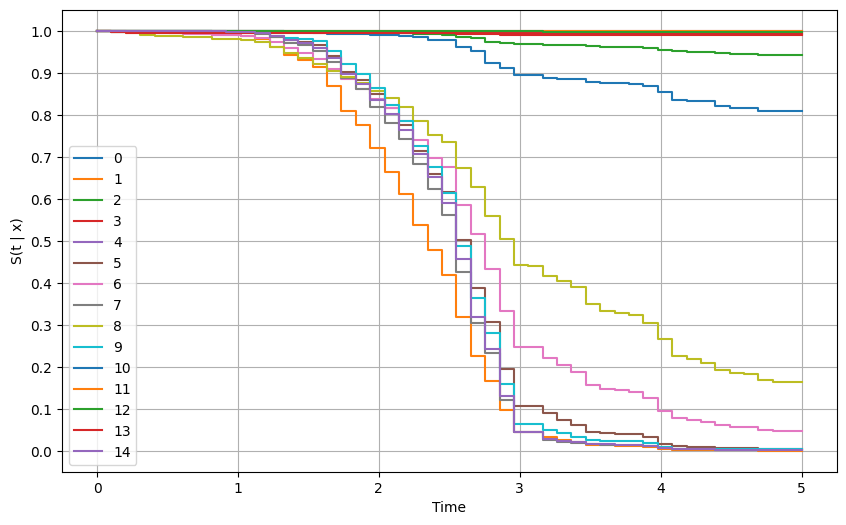

In [30]:
ax = surv.iloc[:, :15].plot(drawstyle='steps-post', figsize=(10, 6))
plt.ylabel('S(t | x)')
plt.xlabel('Time')
plt.grid(True)
plt.yticks([i / 10 for i in range(11)])
# plt.yticks([i / 100 for i in range(101)])
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: '{:.2f}'.format(val)))
plt.show()

It is, therefore, often beneficial to [interpolate the survival estimates](https://arxiv.org/abs/1910.06724).
Linear interpolation (constant density interpolation) can be performed with the `interpolate` method. We also need to choose how many points we want to replace each grid point with. Her we will use 10.

In [31]:
surv = model.interpolate(50).predict_surv_df(x_test)

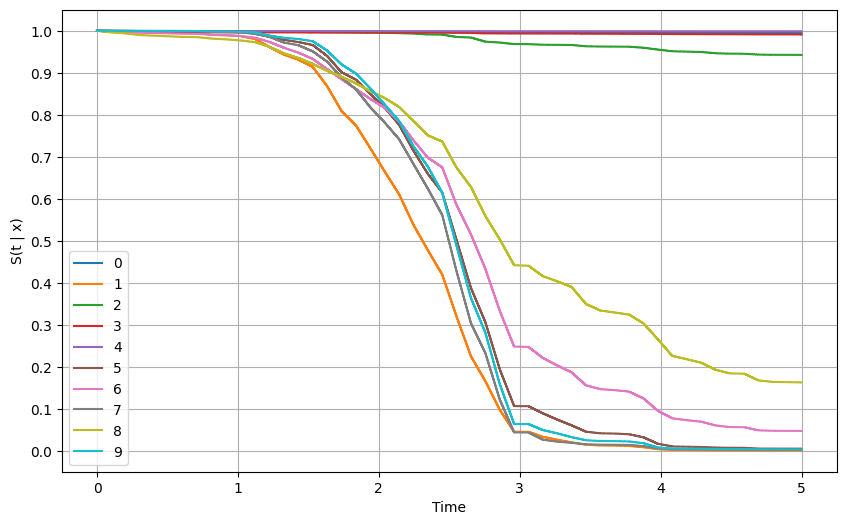

In [32]:
ax = surv.iloc[:, :10].plot(drawstyle='steps-post', figsize=(10, 6))
plt.ylabel('S(t | x)')
plt.xlabel('Time')
plt.grid(True)
plt.yticks([i / 10 for i in range(11)])
# plt.yticks([i / 100 for i in range(101)])
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: '{:.2f}'.format(val)))
plt.show()

## Evaluation

The `EvalSurv` class contains some useful evaluation criteria for time-to-event prediction.
We set `censor_surv = 'km'` to state that we want to use Kaplan-Meier for estimating the censoring distribution.


In [33]:
ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')

#### Concordance

We start with the event-time concordance by [Antolini et al. 2005](https://onlinelibrary.wiley.com/doi/10.1002/sim.2427).

In [34]:
ev.concordance_td('antolini')

0.8789680375259081

#### Brier Score

We can plot the the [IPCW Brier score](https://onlinelibrary.wiley.com/doi/abs/10.1002/%28SICI%291097-0258%2819990915/30%2918%3A17/18%3C2529%3A%3AAID-SIM274%3E3.0.CO%3B2-5) for a given set of times.
Here we just use 100 time-points between the min and max duration in the test set.
Note that the score becomes unstable for the highest times. It is therefore common to disregard the rightmost part of the graph.

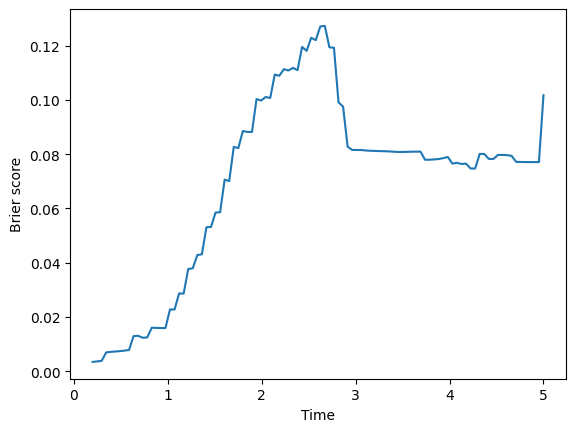

In [35]:
time_grid = np.linspace(durations_test.min(), durations_test.max(), 100)
ev.brier_score(time_grid).plot()
plt.ylabel('Brier score')
_ = plt.xlabel('Time')

#### Negative binomial log-likelihood

In a similar manner, we can plot the the [IPCW negative binomial log-likelihood](https://onlinelibrary.wiley.com/doi/abs/10.1002/%28SICI%291097-0258%2819990915/30%2918%3A17/18%3C2529%3A%3AAID-SIM274%3E3.0.CO%3B2-5).

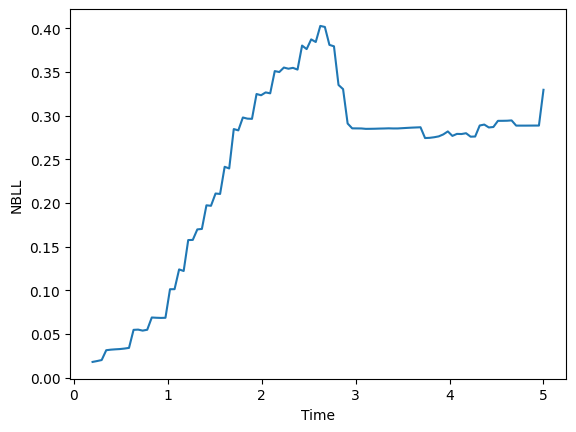

In [36]:
ev.nbll(time_grid).plot()
plt.ylabel('NBLL')
_ = plt.xlabel('Time')

#### Integrated scores

The two time-dependent scores above can be integrated over time to produce a single score [Graf et al. 1999](https://onlinelibrary.wiley.com/doi/abs/10.1002/%28SICI%291097-0258%2819990915/30%2918%3A17/18%3C2529%3A%3AAID-SIM274%3E3.0.CO%3B2-5). In practice this is done by numerical integration over a defined `time_grid`.

In [37]:
ev.integrated_brier_score(time_grid) 

0.06997950957423969

In [38]:
ev.integrated_nbll(time_grid) 

0.24449264883896146

In [39]:
from sklearn.model_selection import KFold
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import os
from sklearn_pandas import DataFrameMapper
import torchtuples as tt
import torch.nn as nn
from pycox.models import LogisticHazard
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index

# Paths to your folders
training_folder = '/kaggle/input/time-to-accident-dataset-2/gog_features/gog_features'
toas_folder = '/kaggle/input/time-to-accident-dataset-2/toas'

# Feature keys
feature_keys = ['frame_embeddings', 'object_level_features', 'graph_embeddings']
FPS = 10

# Number of splits for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

def process_folder(folder_name):
    features_list = []
    durations_list = []
    events_list = []

    for npz_file in os.listdir(folder_name):
        if npz_file.endswith('.npz'):
            file_id = os.path.splitext(npz_file)[0]
            npz_path = os.path.join(folder_name, npz_file)
            
            npz_data = np.load(npz_path)
            combined_features = []
            
            for key in feature_keys:
                if key in npz_data:
                    features = npz_data[key].flatten()
                    combined_features.extend(features)
            
            if combined_features:
                features_list.append(combined_features)
                txt_path = os.path.join(toas_folder, f"{file_id}.txt")
                
                if os.path.exists(txt_path):
                    with open(txt_path, 'r') as f:
                        frame_count = float(f.read().strip())
                    duration = frame_count / FPS
                    event = 1
                else:
                    duration = 5  # Censored event
                    event = 0
                
                durations_list.append(duration)
                events_list.append(event)

    num_features = len(features_list[0]) if features_list else 0
    data = pd.DataFrame(features_list, columns=[f'x{i}' for i in range(num_features)])
    data['duration'] = durations_list
    data['event'] = events_list
    
    return data

def apply_upsampling(data):
    bin_size = 0.5
    bins = np.arange(0, 5 + bin_size, bin_size)
    data['duration_bin'] = pd.cut(data['duration'], bins=bins, include_lowest=True)
    bin_counts = data['duration_bin'].value_counts()
    median_count = int(bin_counts.median())
    median_count = max(median_count, bin_counts.max(), 1)
    
    bins_to_upsample = [b for b in bin_counts.index if bin_counts[b] < median_count and not (2.5 <= b.left < 3.0)]
    upsampled_data = []
    
    for bin_range in bins_to_upsample:
        bin_data = data[data['duration_bin'] == bin_range]
        if not bin_data.empty:
            upsampled_bin = resample(bin_data, replace=True, n_samples=median_count, random_state=42)
            upsampled_data.append(upsampled_bin)
    
    upsampled_data.append(data)
    data = pd.concat(upsampled_data).drop(columns=['duration_bin']).sample(frac=1, random_state=42).reset_index(drop=True)
    
    return data

class CustomNet(nn.Module):
    def __init__(self, in_features, out_features, dropout_rates=[0.3, 0.4, 0.5], batch_norm=True):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0]),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[1]),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32) if batch_norm else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(dropout_rates[2]),

            nn.Linear(32, out_features)
        )

    def forward(self, x):
        return self.layers(x)

# Process full dataset
data = process_folder(training_folder)

test_size = 0.2
val_size = 0.2

df_test = data.sample(frac=test_size, random_state=42)
data = data.drop(df_test.index)

cols_standardize = [f'x{i}' for i in range(44800)]  
cols_leave = []  

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

def get_target(df):
    return (df['duration'].values, df['event'].values)

num_durations = 50
labtrans = LogisticHazard.label_transform(num_durations)

c_index_scores = []
integrated_nbll_scores = []
integrated_brier_scores = []

time_grid = np.linspace(df_test['duration'].min(), df_test['duration'].max(), 100)

for fold, (train_idx, val_idx) in enumerate(kf.split(data)):
    print(f"Fold {fold + 1}/{n_splits}")
    
    df_train = data.iloc[train_idx]
    df_val = data.iloc[val_idx]
    
    # df_train = apply_upsampling(df_train)
    
    x_train = x_mapper.fit_transform(df_train).astype('float32')
    x_val = x_mapper.transform(df_val).astype('float32')
    x_test = x_mapper.transform(df_test).astype('float32')
    
    y_train = labtrans.fit_transform(*get_target(df_train))
    y_val = labtrans.transform(*get_target(df_val))
    durations_test, events_test = get_target(df_test)
    
    net = CustomNet(x_train.shape[1], labtrans.out_features)
    model = LogisticHazard(net, tt.optim.Adam(0.01), duration_index=labtrans.cuts)
    model.fit(x_train, y_train, batch_size=64, epochs=100, callbacks=[tt.cb.EarlyStopping(patience=5, min_delta=0.001)], val_data=(x_val, y_val))
    
    ev = EvalSurv(model.predict_surv_df(x_test), durations_test, events_test, censor_surv='km')
    
    print(f"C-index: {ev.concordance_td('antolini'):.4f}")
    print(f"Integrated NBLL: {ev.integrated_nbll(time_grid):.4f}")
    print(f"Integrated Brier Score: {ev.integrated_brier_score(time_grid):.4f}")
    
    c_index_scores.append(ev.concordance_td('antolini'))
    integrated_nbll_scores.append(ev.integrated_nbll(time_grid))
    integrated_brier_scores.append(ev.integrated_brier_score(time_grid))
    
print("\n")
print(f"Average C-index: {np.mean(c_index_scores):.4f}")
print(f"Average Integrated NBLL: {np.mean(integrated_nbll_scores):.4f}")
print(f"Average Integrated Brier Score: {np.mean(integrated_brier_scores):.4f}")


Fold 1/5
0:	[0s / 0s],		train_loss: 14.3451,	val_loss: 6.9353
1:	[0s / 1s],		train_loss: 3.5998,	val_loss: 2.3337
2:	[0s / 2s],		train_loss: 2.6409,	val_loss: 1.9622
3:	[0s / 2s],		train_loss: 2.3827,	val_loss: 1.8698
4:	[0s / 3s],		train_loss: 2.2177,	val_loss: 1.8216
5:	[0s / 4s],		train_loss: 2.1779,	val_loss: 1.8115
6:	[0s / 4s],		train_loss: 2.0747,	val_loss: 1.8038
7:	[0s / 5s],		train_loss: 2.1112,	val_loss: 1.7964
8:	[0s / 6s],		train_loss: 2.0002,	val_loss: 1.7898
9:	[0s / 7s],		train_loss: 1.9649,	val_loss: 1.7822
10:	[0s / 7s],		train_loss: 1.9314,	val_loss: 1.7811
11:	[0s / 8s],		train_loss: 1.8810,	val_loss: 1.7702
12:	[0s / 9s],		train_loss: 1.8941,	val_loss: 1.7399
13:	[0s / 9s],		train_loss: 1.8524,	val_loss: 1.7499
14:	[0s / 10s],		train_loss: 1.8504,	val_loss: 1.7466
15:	[0s / 11s],		train_loss: 1.8336,	val_loss: 1.7252
16:	[0s / 11s],		train_loss: 1.7997,	val_loss: 1.7318
17:	[0s / 12s],		train_loss: 1.7655,	val_loss: 1.7259
18:	[0s / 13s],		train_loss: 1.7860,	val_l

/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


0:	[0s / 0s],		train_loss: 16.2042,	val_loss: 8.8517
1:	[0s / 1s],		train_loss: 4.0578,	val_loss: 2.5604
2:	[0s / 2s],		train_loss: 2.5176,	val_loss: 2.1209
3:	[0s / 2s],		train_loss: 2.3471,	val_loss: 2.0062
4:	[0s / 3s],		train_loss: 2.2684,	val_loss: 1.9891
5:	[0s / 4s],		train_loss: 2.1607,	val_loss: 1.9755
6:	[0s / 5s],		train_loss: 2.1250,	val_loss: 1.9569
7:	[0s / 6s],		train_loss: 2.0534,	val_loss: 1.9350
8:	[0s / 6s],		train_loss: 2.0353,	val_loss: 1.9076
9:	[0s / 7s],		train_loss: 2.0065,	val_loss: 1.8785
10:	[0s / 8s],		train_loss: 1.9364,	val_loss: 1.8620
11:	[0s / 8s],		train_loss: 1.9263,	val_loss: 1.8426
12:	[0s / 9s],		train_loss: 1.9033,	val_loss: 1.8403
13:	[0s / 10s],		train_loss: 1.9332,	val_loss: 1.8388
14:	[0s / 11s],		train_loss: 1.8406,	val_loss: 1.8316
15:	[0s / 11s],		train_loss: 1.8219,	val_loss: 1.8332
16:	[0s / 12s],		train_loss: 1.8172,	val_loss: 1.8262
17:	[0s / 13s],		train_loss: 1.8105,	val_loss: 1.8079
18:	[0s / 13s],		train_loss: 1.8333,	val_loss: 1.8

/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


0:	[0s / 0s],		train_loss: 14.7484,	val_loss: 8.2752
1:	[0s / 1s],		train_loss: 3.7027,	val_loss: 2.4153
2:	[0s / 2s],		train_loss: 2.5619,	val_loss: 2.1596
3:	[0s / 2s],		train_loss: 2.3419,	val_loss: 2.0432
4:	[0s / 3s],		train_loss: 2.1869,	val_loss: 1.9815
5:	[0s / 4s],		train_loss: 2.1364,	val_loss: 1.9331
6:	[0s / 4s],		train_loss: 2.0312,	val_loss: 1.9238
7:	[0s / 5s],		train_loss: 2.1010,	val_loss: 1.9254
8:	[0s / 6s],		train_loss: 2.0083,	val_loss: 1.9085
9:	[0s / 7s],		train_loss: 1.9531,	val_loss: 1.8856
10:	[0s / 7s],		train_loss: 1.9303,	val_loss: 1.8649
11:	[0s / 8s],		train_loss: 1.8888,	val_loss: 1.8866
12:	[0s / 9s],		train_loss: 1.8566,	val_loss: 1.8881
13:	[0s / 10s],		train_loss: 1.9063,	val_loss: 1.8717
14:	[0s / 10s],		train_loss: 1.8017,	val_loss: 1.8734
15:	[0s / 11s],		train_loss: 1.8198,	val_loss: 1.8790
C-index: 0.8347
Integrated NBLL: 0.2671
Integrated Brier Score: 0.0816
Fold 4/5


/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


0:	[0s / 0s],		train_loss: 14.5521,	val_loss: 7.0504
1:	[0s / 1s],		train_loss: 3.7103,	val_loss: 2.3909
2:	[0s / 2s],		train_loss: 2.5937,	val_loss: 2.0202
3:	[0s / 2s],		train_loss: 2.3641,	val_loss: 1.9827
4:	[0s / 3s],		train_loss: 2.2963,	val_loss: 1.8781
5:	[0s / 4s],		train_loss: 2.1805,	val_loss: 1.8313
6:	[0s / 4s],		train_loss: 2.1204,	val_loss: 1.8291
7:	[0s / 5s],		train_loss: 2.0406,	val_loss: 1.8350
8:	[0s / 6s],		train_loss: 2.0555,	val_loss: 1.8136
9:	[0s / 6s],		train_loss: 1.9907,	val_loss: 1.8076
10:	[0s / 7s],		train_loss: 1.9615,	val_loss: 1.8183
11:	[0s / 8s],		train_loss: 1.9008,	val_loss: 1.7993
12:	[0s / 9s],		train_loss: 1.9235,	val_loss: 1.7954
13:	[0s / 9s],		train_loss: 1.8944,	val_loss: 1.8347
14:	[0s / 10s],		train_loss: 1.8822,	val_loss: 1.8101
15:	[0s / 11s],		train_loss: 1.7890,	val_loss: 1.8075
16:	[0s / 11s],		train_loss: 1.8076,	val_loss: 1.8059
17:	[0s / 12s],		train_loss: 1.8196,	val_loss: 1.7982
C-index: 0.8396
Integrated NBLL: 0.2644
Integrated 

/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


0:	[0s / 0s],		train_loss: 14.9902,	val_loss: 8.3167
1:	[0s / 1s],		train_loss: 3.9327,	val_loss: 2.2783
2:	[0s / 2s],		train_loss: 2.5886,	val_loss: 1.9703
3:	[0s / 2s],		train_loss: 2.4035,	val_loss: 1.8613
4:	[0s / 3s],		train_loss: 2.3031,	val_loss: 1.7997
5:	[0s / 4s],		train_loss: 2.1595,	val_loss: 1.7772
6:	[0s / 4s],		train_loss: 2.1449,	val_loss: 1.7414
7:	[0s / 5s],		train_loss: 2.0992,	val_loss: 1.7184
8:	[0s / 6s],		train_loss: 2.0820,	val_loss: 1.7112
9:	[0s / 7s],		train_loss: 2.0367,	val_loss: 1.7062
10:	[0s / 7s],		train_loss: 1.9263,	val_loss: 1.7136
11:	[0s / 8s],		train_loss: 1.9392,	val_loss: 1.6963
12:	[0s / 9s],		train_loss: 1.9758,	val_loss: 1.7010
13:	[0s / 9s],		train_loss: 1.9102,	val_loss: 1.6820
14:	[0s / 10s],		train_loss: 1.9150,	val_loss: 1.6825
15:	[0s / 11s],		train_loss: 1.8359,	val_loss: 1.6846
16:	[0s / 11s],		train_loss: 1.8858,	val_loss: 1.6775
17:	[0s / 12s],		train_loss: 1.7806,	val_loss: 1.6577
18:	[0s / 13s],		train_loss: 1.7914,	val_loss: 1.67

/usr/local/lib/python3.10/dist-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.load(path, **kwargs))


# Next

You can now look at other examples of survival methods in the [examples folder](https://nbviewer.jupyter.org/github/havakv/pycox/tree/master/examples).
Or, alternatively take a look at

- the more advanced training procedures in the notebook [02_introduction.ipynb](https://nbviewer.jupyter.org/github/havakv/pycox/blob/master/examples/02_introduction.ipynb).
- other network architectures that combine autoencoders and survival networks in the notebook [03_network_architectures.ipynb](https://nbviewer.jupyter.org/github/havakv/pycox/blob/master/examples/03_network_architectures.ipynb).
- working with DataLoaders and convolutional networks in the notebook [04_mnist_dataloaders_cnn.ipynb](https://nbviewer.jupyter.org/github/havakv/pycox/blob/master/examples/04_mnist_dataloaders_cnn.ipynb).